In [ ]:
##Check for another ANN file for reference file - fashion MNIST

In [1]:
import pandas as pd
import numpy as np
##Visualisation libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns
#Evaluation libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

##Deep learning
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
##from keras.layers.core import Dense,Activation,Dropout
from keras.layers import Dense, Dropout, Activation 

from keras.datasets import mnist
##from keras.utils.np_utils import to_categorical
from keras.utils import to_categorical
##from keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasClassifier







2026-08-17 12:05:36.430046: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [27]:
(x_train_digit,y_train_digit),(x_test_digit,y_test_digit)=mnist.load_data()

In [37]:
x_train_digit[1][27]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8)

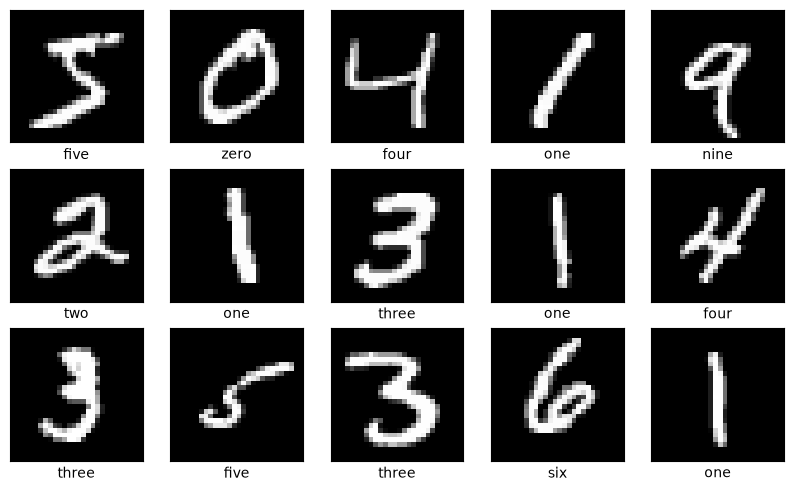

In [30]:
##To visualise the xtrain values in image

col_names=['zero','one','two','three','four','five','six','seven','eight','nine']

##plt.figure(fig_size=(10,10))
plt.figure(figsize=(10, 10))  
for i in range (15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train_digit[i],cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

In [31]:
x_train_digit.shape

(60000, 28, 28)

In [32]:
x_test_digit.shape

(10000, 28, 28)

In [33]:
y_train_digit.shape

(60000,)

In [38]:
##Preprocessing
## ANN will accept input in 2D only, so we have to convert 3D input to 2D by multiplying rows*columns (28*28=784)
x_train_digit=x_train_digit.reshape(60000,784)
x_test_digit=x_test_digit.reshape(10000,784)

In [39]:
##Preprocessing
## ANN will accept input in 2D only, so we have to convert 1D input to 2D using one hot encoder
#Encoding Digit mnist labels
y_train_digit=to_categorical(y_train_digit,num_classes=10)
y_test_digit=to_categorical(y_test_digit,num_classes=10)

In [40]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [81]:
y_test_digit[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [43]:
##Creating base neural network #( ANN is a Sequntial process  ##FeedForward Neuralnetwork )
##Procedure ##FeedForward Neuralnetwork

model=keras.Sequential([
# Input Layer: Takes the 784 flattened pixels and maps to 256 nodes
layers.Dense(256, activation='relu', input_shape=(784,)),
    
# Hidden Layer 1: Drops down to 64 nodes to extract deeper features
layers.Dense(64, activation='relu'),
    
# Hidden Layer 2: Another 64-node layer to refine patterns
layers.Dense(64, activation='relu'),
    
# Output Layer: FIXED to softmax for 10 distinct digit probabilities 
layers.Dense(10,activation='sigmoid') ## activation='softmax'
])

In [44]:
model.summary()

##Param values calc: output channel number = 
  ##256*(784+1)
  ##64*(256+1)
  ##64*(64+1)
  ##10*(64+1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
##Compile the model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [48]:
history=model.fit(x_train_digit,y_train_digit,batch_size=100,epochs=10,validation_data=(x_test_digit,y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7932 - loss: 1.3859 - val_accuracy: 0.8814 - val_loss: 0.3539
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8953 - loss: 0.2697 - val_accuracy: 0.8969 - val_loss: 0.2453
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9089 - loss: 0.1868 - val_accuracy: 0.8986 - val_loss: 0.2109
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9018 - loss: 0.1496 - val_accuracy: 0.8964 - val_loss: 0.1749
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8961 - loss: 0.1330 - val_accuracy: 0.8886 - val_loss: 0.1804
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9009 - loss: 0.1126 - val_accuracy: 0.8966 - val_loss: 0.1680
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9043 - loss: 0.1014 - val_accuracy: 0.9022 - val_loss: 0.1435
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9039 - loss: 0.1010 - val_accura

In [49]:
##Predicting the lables# Testing

y_predict= model.predict(x_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [50]:
y_predict

array([[9.33805466e-01, 9.96063888e-01, 9.65110242e-01, ...,
        1.00000000e+00, 6.23933374e-05, 9.99998629e-01],
       [3.31677467e-04, 9.87452328e-01, 1.00000000e+00, ...,
        9.95618522e-01, 9.13087726e-02, 8.99658144e-01],
       [9.99804020e-01, 1.00000000e+00, 9.99205947e-01, ...,
        9.99981403e-01, 9.99997377e-01, 9.99991000e-01],
       ...,
       [4.81059920e-04, 8.45855197e-07, 1.92175095e-03, ...,
        9.04841185e-01, 9.55446655e-09, 9.93699431e-01],
       [6.20995283e-01, 9.99975801e-01, 7.53376544e-01, ...,
        4.15491760e-01, 1.00000000e+00, 1.00000000e+00],
       [9.81674731e-01, 1.48084670e-12, 1.05272166e-10, ...,
        1.59416533e-08, 2.51913576e-07, 1.32362482e-06]], dtype=float32)

In [54]:
##Test data
y_predicts=np.argmax(y_predict,axis=1) ## getting the index of maximum value in the encoded vector
y_predicts 


array([7, 2, 1, ..., 4, 3, 6])

In [55]:
##Actual data
y_test_digit_eval=np.argmax(y_test_digit,axis=1) 
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6])

In [56]:
#Confusion Matrix

con_mat=confusion_matrix(y_test_digit_eval,y_predicts)
con_mat

array([[ 966,    0,    2,    3,    1,    1,    4,    1,    2,    0],
       [   1, 1114,    3,    3,    0,    1,    1,    1,   10,    1],
       [   3,    2,  993,   17,    0,    1,    1,    9,    6,    0],
       [   0,   71,   39,  889,    0,    2,    0,    3,    3,    3],
       [   0,    0,    5,    1,  941,    1,    8,    2,    1,   23],
       [   4,   64,    1,  558,    1,  251,    3,    0,    7,    3],
       [ 196,    3,    4,    3,    3,   81,  666,    0,    2,    0],
       [   1,    7,   10,   21,    1,    0,    0,  986,    0,    2],
       [   2,    0,    4,   21,    1,    4,    3,    6,  926,    7],
       [   2,    2,    4,   15,    9,    1,    0,   11,    4,  961]])

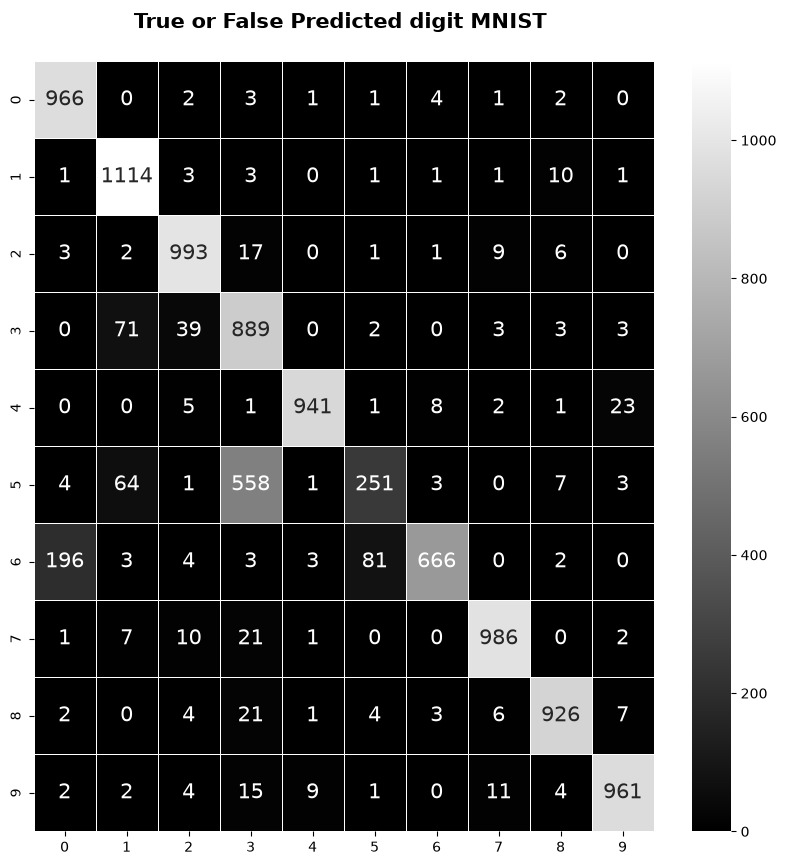

In [60]:
##plt.style.use('seaborn-deep')
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False Predicted digit MNIST \n',fontweight='bold',fontsize=15)
plt.show()

In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_test_digit_eval,y_predicts))

## learnt 4 well - 97% in f1 score 

              precision    recall  f1-score   support

           0       0.82      0.99      0.90       980
           1       0.88      0.98      0.93      1135
           2       0.93      0.96      0.95      1032
           3       0.58      0.88      0.70      1010
           4       0.98      0.96      0.97       982
           5       0.73      0.28      0.41       892
           6       0.97      0.70      0.81       958
           7       0.97      0.96      0.96      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.87     10000
   macro avg       0.88      0.86      0.85     10000
weighted avg       0.88      0.87      0.86     10000



In [62]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


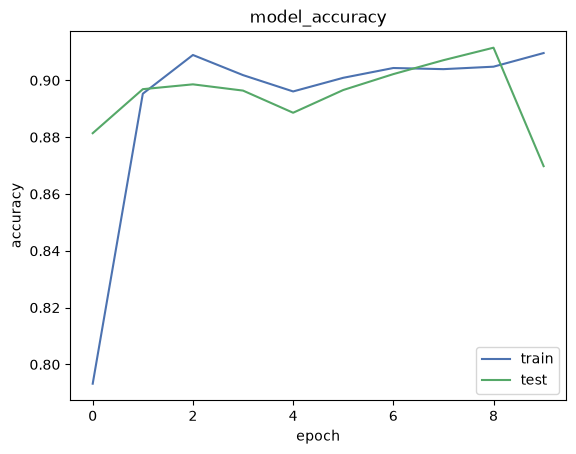

In [63]:
#summary for accuracy #accuracy graph 
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model_accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

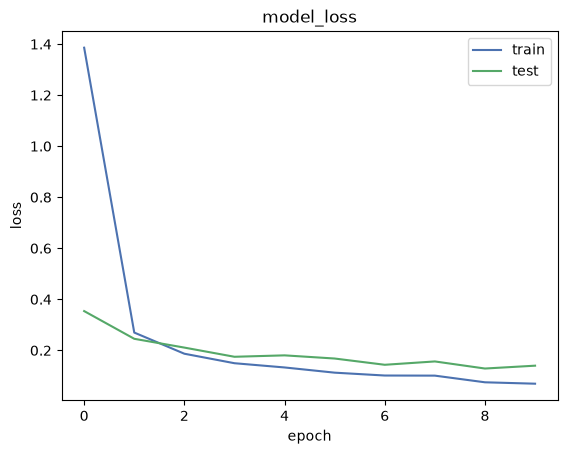

In [64]:
#summary for loss #loss graph 
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model_loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

In [76]:
#Before submitting , validate the model for single input

y_predict_single = model.predict(x_test_digit[[2]])
y_predict_single=np.argmax(y_predict_single,axis=1)
y_test_digit_eval=np.argmax(y_test_digit[[2]],axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


In [77]:
y_predict_single=y_predict_single[0]


In [79]:
y_test_digit_eval=y_test_digit_eval[0]

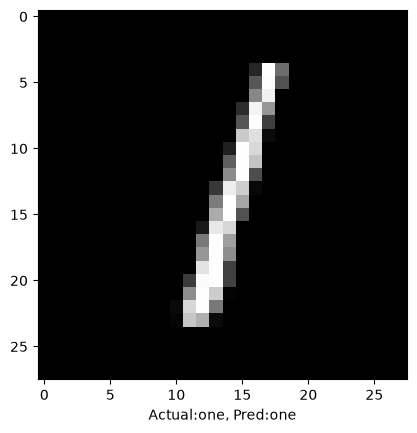

In [80]:
#Names of numbers in the dataset in order
col_names=['zero','one','two','three','four','five','six','seven','eight','nine']

##Visualising the digits
plt.imshow(x_test_digit[2].reshape(28,28),cmap='gray')
plt.xlabel("Actual:{}, Pred:{}".format(col_names[y_test_digit_eval],col_names[y_predict_single]))
plt.show()

In [4]:
##%pip install scikeras

Note: you may need to restart the kernel to use updated packages.


In [4]:
#%pip install --upgrade --force-reinstall numpy==1.26.4 ml-dtypes==0.3.1 scipy==1.15.2 tensorflow==2.16.1


  Using cached numpy-1.26.4-cp312-cp312-macosx_10_9_x86_64.whl.metadata (61 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached h5py-3.16.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (3.0 kB)
  Using cached libclang-18.1.1-py2.py3-none-macosx_10_9_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached protobuf-4.25.9-cp37-abi3-macosx_10_9_universal2.whl.metadata (541 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6

In [ ]:
# %pip install pydot graphviz

(DLenv1) MaxMachine:AI - Mohana Max$ pip install tensorflow keras numpy pandas matplotlib ipykernel
Collecting tensorflow
  Downloading tensorflow-2.16.2-cp312-cp312-macosx_10_15_x86_64.whl.metadata (4.1 kB)
Collecting keras
  Downloading keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)


In [2]:
#!pip install seaborn

In [4]:
#%pip install scikit-learn

  Using cached numpy-2.5.2-cp312-cp312-macosx_10_13_x86_64.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 3.7 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 3.2 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 3.8 MB/s  0:00:04m0:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [numpy]
      Successfully uninstalled numpy-1.26.4━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.
